In [ ]:
# ============================================================
# PNEUMONIA DETECTION 
# Ensemble: ResNet50 + DenseNet121 with CBAM Attention
# Train/Test: Local Dataset
# Validation: HuggingFace Dataset
# ============================================================

# -----------------------------
# IMPORTS
# -----------------------------
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import models
from torchvision.datasets import ImageFolder

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    confusion_matrix, roc_curve,
    precision_recall_curve
)

from datasets import load_dataset
from google.colab import drive

# -----------------------------
# MOUNT DRIVE
# -----------------------------
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [58]:
# -----------------------------
# REPRODUCIBILITY
# -----------------------------
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [59]:
# ============================================================
# PATHS
# ============================================================
RAW_DATA_DIR = "/content/drive/MyDrive/data"
SPLIT_ROOT   = "/content/drive/MyDrive/chest_xray"
FIG_DIR      = "/content/drive/MyDrive/research_figures"
MODEL_PATH   = "/content/drive/MyDrive/best_pneumonia_model.pth"

os.makedirs(FIG_DIR, exist_ok=True)

TRAIN_DIR = os.path.join(SPLIT_ROOT, "train")
TEST_DIR  = os.path.join(SPLIT_ROOT, "test")

CLASSES = ["NORMAL", "PNEUMONIA"]

In [60]:
# ============================================================
# DATA SPLITTING (TRAIN / TEST ONLY)
# ============================================================
def split_dataset():
    if os.path.exists(SPLIT_ROOT):
        print("Dataset already split. Skipping.")
        return

    for split in ["train", "test"]:
        for cls in CLASSES:
            os.makedirs(os.path.join(SPLIT_ROOT, split, cls), exist_ok=True)

    files, labels = [], []

    for idx, cls in enumerate(CLASSES):
        cls_dir = os.path.join(RAW_DATA_DIR, cls)
        for img in os.listdir(cls_dir):
            files.append(os.path.join(cls_dir, img))
            labels.append(idx)

    train_f, test_f, train_l, test_l = train_test_split(
        files, labels,
        test_size=0.15,
        stratify=labels,
        random_state=42
    )

    def copy_files(f_list, l_list, split):
        for f, l in zip(f_list, l_list):
            shutil.copy(f, os.path.join(SPLIT_ROOT, split, CLASSES[l]))

    copy_files(train_f, train_l, "train")
    copy_files(test_f, test_l, "test")

    print("Train/Test split completed.")

split_dataset()

Dataset already split. Skipping.


In [61]:
# ============================================================
# DATA AUGMENTATION
# ============================================================
def to_rgb(image, **kwargs):
    # Ensure numpy array
    image = np.asarray(image)

    # Ensure uint8 for Albumentations (CRITICAL for CLAHE)
    if image.dtype != np.uint8:
        image = (image * 255).astype(np.uint8)

    # Handle grayscale formats
    if image.ndim == 2:                     # (H, W)
        image = np.stack([image]*3, axis=-1)
    elif image.ndim == 3 and image.shape[2] == 1:  # (H, W, 1)
        image = np.repeat(image, 3, axis=2)

    return image


train_transform = A.Compose([
    A.Resize(224, 224),
    A.Lambda(image=to_rgb),          # convert to uint8 RGB FIRST
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(0.05, 0.1, 10, p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.CLAHE(p=0.3),                  # now SAFE
    A.Normalize(),                   # AFTER CLAHE
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(224, 224),
    A.Lambda(image=to_rgb),
    A.Normalize(),
    ToTensorV2()
])


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [62]:
# ============================================================
# DATASET WRAPPER
# ============================================================
class AlbumentationsDataset(Dataset):
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        image = np.array(image)
        image = self.transform(image=image)["image"]
        return image, torch.tensor(label, dtype=torch.long)


In [63]:
# ============================================================
# LOAD LOCAL DATA (TRAIN / TEST)
# ============================================================
train_base = ImageFolder(TRAIN_DIR)
test_base  = ImageFolder(TEST_DIR)

train_dataset = AlbumentationsDataset(train_base, train_transform)
test_dataset  = AlbumentationsDataset(test_base, val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)



In [64]:
x, y = next(iter(train_loader))
print(x.shape, x.dtype)


torch.Size([16, 3, 224, 224]) torch.float32


In [65]:
# ============================================================
# LOAD HUGGINGFACE VALIDATION DATA
# ============================================================
hf_val = load_dataset("hf-vision/chest-xray-pneumonia", split="test")

class HFWrapper(Dataset):
    def __init__(self, hf_dataset, transform):
        self.ds = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        image = np.array(self.ds[idx]["image"])
        label = self.ds[idx]["label"]
        image = self.transform(image=image)["image"]
        return image, torch.tensor(label, dtype=torch.long)

val_dataset = HFWrapper(hf_val, val_transform)
val_loader  = DataLoader(val_dataset, 16, shuffle=False, num_workers=2)


In [66]:
# ============================================================
# CLASS WEIGHTS (IMBALANCE HANDLING)
# ============================================================
targets = train_base.targets
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(targets),
    y=targets
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)


In [67]:
# ============================================================
# CBAM MODULE
# ============================================================
class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.channel = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // reduction, 1),
            nn.ReLU(),
            nn.Conv2d(channels // reduction, channels, 1),
            nn.Sigmoid()
        )
        self.spatial = nn.Sequential(
            nn.Conv2d(2, 1, 7, padding=3),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x * self.channel(x)
        avg = torch.mean(x, dim=1, keepdim=True)
        mx, _ = torch.max(x, dim=1, keepdim=True)
        return x * self.spatial(torch.cat([avg, mx], dim=1))


In [68]:
# ============================================================
# MODELS
# ============================================================
class ResNet50_CBAM(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet50(weights="IMAGENET1K_V1")
        self.features = nn.Sequential(*list(base.children())[:-2])
        self.cbam = CBAM(2048)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(2048, 2)

    def forward(self, x):
        x = self.features(x)
        x = self.cbam(x)
        x = self.pool(x).flatten(1)
        return self.fc(x)

class DenseNet121_CBAM(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.densenet121(weights="IMAGENET1K_V1")
        self.features = base.features
        self.cbam = CBAM(1024)
        self.fc = nn.Linear(1024, 2)

    def forward(self, x):
        x = self.features(x)
        x = self.cbam(x)
        x = nn.functional.relu(x)
        x = nn.functional.adaptive_avg_pool2d(x, 1).flatten(1)
        return self.fc(x)

class EnsembleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.r = ResNet50_CBAM()
        self.d = DenseNet121_CBAM()
        self.w = nn.Parameter(torch.tensor([0.5, 0.5]))

    def forward(self, x):
        w = torch.softmax(self.w, dim=0)
        return w[0] * self.r(x) + w[1] * self.d(x)


In [69]:
# ============================================================
# FOCAL LOSS
# ============================================================
class FocalLoss(nn.Module):
    def __init__(self, weight, gamma=2, smoothing=0.1):
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(weight=weight, label_smoothing=smoothing)

    def forward(self, logits, targets):
        ce = self.ce(logits, targets)
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


In [70]:
# ============================================================
# EVALUATION FUNCTION
# ============================================================
def evaluate(model, loader):
    model.eval()
    y, p, s = [], [], []

    with torch.no_grad():
        for x, t in loader:
            x = x.to(DEVICE)
            out = model(x)
            prob = torch.softmax(out, 1)[:, 1]
            pred = torch.argmax(out, 1)
            y.extend(t.numpy())
            p.extend(pred.cpu().numpy())
            s.extend(prob.cpu().numpy())

    return {
        "acc": accuracy_score(y, p),
        "auc": roc_auc_score(y, s),
        "y": y, "p": p, "s": s
    }


In [71]:
# ============================================================
# TRAINING WITH EARLY STOPPING (WITH PRINTING)
# ============================================================
def train_model(train_loader, val_loader, epochs=40, patience=7):
    model = EnsembleModel().to(DEVICE)
    opt = optim.AdamW(model.parameters(), lr=1e-4)
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    loss_fn = FocalLoss(weight=class_weights)

    best_auc = 0.0
    wait = 0

    history = {
        "loss": [],
        "val_acc": [],
        "val_auc": []
    }

    print(" Training started...\n")

    for e in range(epochs):
        # ----------------------------
        # TRAINING PHASE
        # ----------------------------
        model.train()
        running_loss = 0.0

        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            opt.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward()
            opt.step()

            running_loss += loss.item()

        sch.step()

        avg_loss = running_loss / len(train_loader)

        # ----------------------------
        # VALIDATION PHASE
        # ----------------------------
        metrics = evaluate(model, val_loader)
        val_acc = metrics["acc"]
        val_auc = metrics["auc"]

        # ----------------------------
        # SAVE HISTORY
        # ----------------------------
        history["loss"].append(avg_loss)
        history["val_acc"].append(val_acc)
        history["val_auc"].append(val_auc)

        # ----------------------------
        # PRINT EPOCH RESULTS
        # ----------------------------
        print(
            f"Epoch [{e+1:02d}/{epochs}] | "
            f"Loss: {avg_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Val AUC: {val_auc:.4f}",
            flush=True
        )

        # ----------------------------
        # EARLY STOPPING CHECK
        # ----------------------------
        if val_auc > best_auc:
            best_auc = val_auc
            wait = 0
            torch.save(model.state_dict(), MODEL_PATH)
            print(" Best model saved.\n")
        else:
            wait += 1
            print(f" No improvement. EarlyStopping counter: {wait}/{patience}\n")

            if wait >= patience:
                print(
                    f" Early stopping triggered at epoch {e+1}. "
                    f"Best Val AUC: {best_auc:.4f}"
                )
                break

    # ----------------------------
    # LOAD BEST MODEL
    # ----------------------------
    model.load_state_dict(torch.load(MODEL_PATH))
    print(" Training completed. Best model loaded.\n")

    return model, history


In [72]:
# ============================================================
# TRAIN
# ============================================================
model, history = train_model(train_loader, val_loader)

 Training started...

Epoch [01/40] | Loss: 0.0448 | Val Acc: 0.8814 | Val AUC: 0.9519
 Best model saved.

Epoch [02/40] | Loss: 0.0340 | Val Acc: 0.8894 | Val AUC: 0.9476
 No improvement. EarlyStopping counter: 1/7

Epoch [03/40] | Loss: 0.0278 | Val Acc: 0.8542 | Val AUC: 0.9512
 No improvement. EarlyStopping counter: 2/7

Epoch [04/40] | Loss: 0.0271 | Val Acc: 0.9375 | Val AUC: 0.9555
 Best model saved.

Epoch [05/40] | Loss: 0.0251 | Val Acc: 0.8221 | Val AUC: 0.9155
 No improvement. EarlyStopping counter: 1/7

Epoch [06/40] | Loss: 0.0226 | Val Acc: 0.9087 | Val AUC: 0.9463
 No improvement. EarlyStopping counter: 2/7

Epoch [07/40] | Loss: 0.0234 | Val Acc: 0.8926 | Val AUC: 0.9469
 No improvement. EarlyStopping counter: 3/7

Epoch [08/40] | Loss: 0.0234 | Val Acc: 0.8846 | Val AUC: 0.9279
 No improvement. EarlyStopping counter: 4/7

Epoch [09/40] | Loss: 0.0217 | Val Acc: 0.9103 | Val AUC: 0.9267
 No improvement. EarlyStopping counter: 5/7

Epoch [10/40] | Loss: 0.0211 | Val Acc

In [75]:
# Saving Graphs to the drive

FIG_DIR = "/content/drive/MyDrive/research_Paper_figures"
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 12

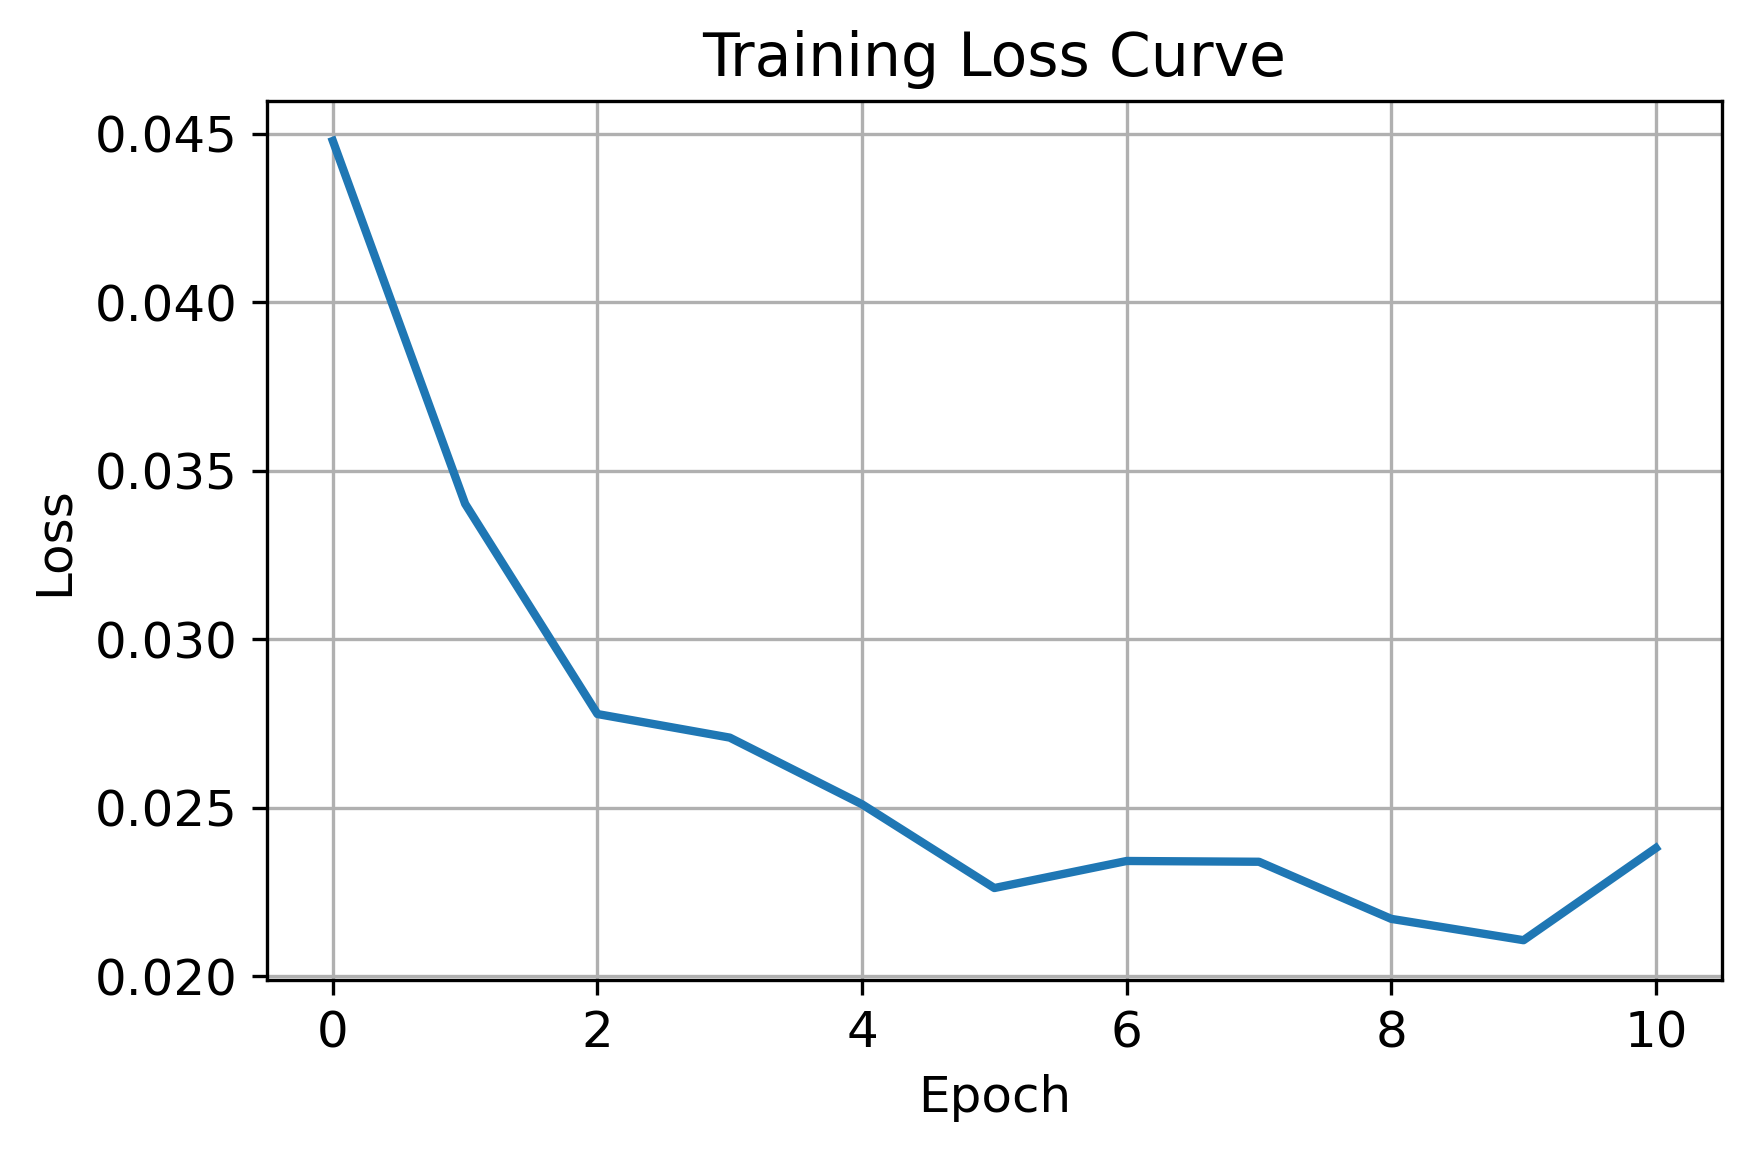

In [76]:

# ============================================================
# PLOTS (FOR RESEARCH PAPER)
# ============================================================

# Loss Curve
plt.figure(figsize=(6,4))
plt.plot(history["loss"], linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/training_loss.png", bbox_inches="tight")
plt.show()



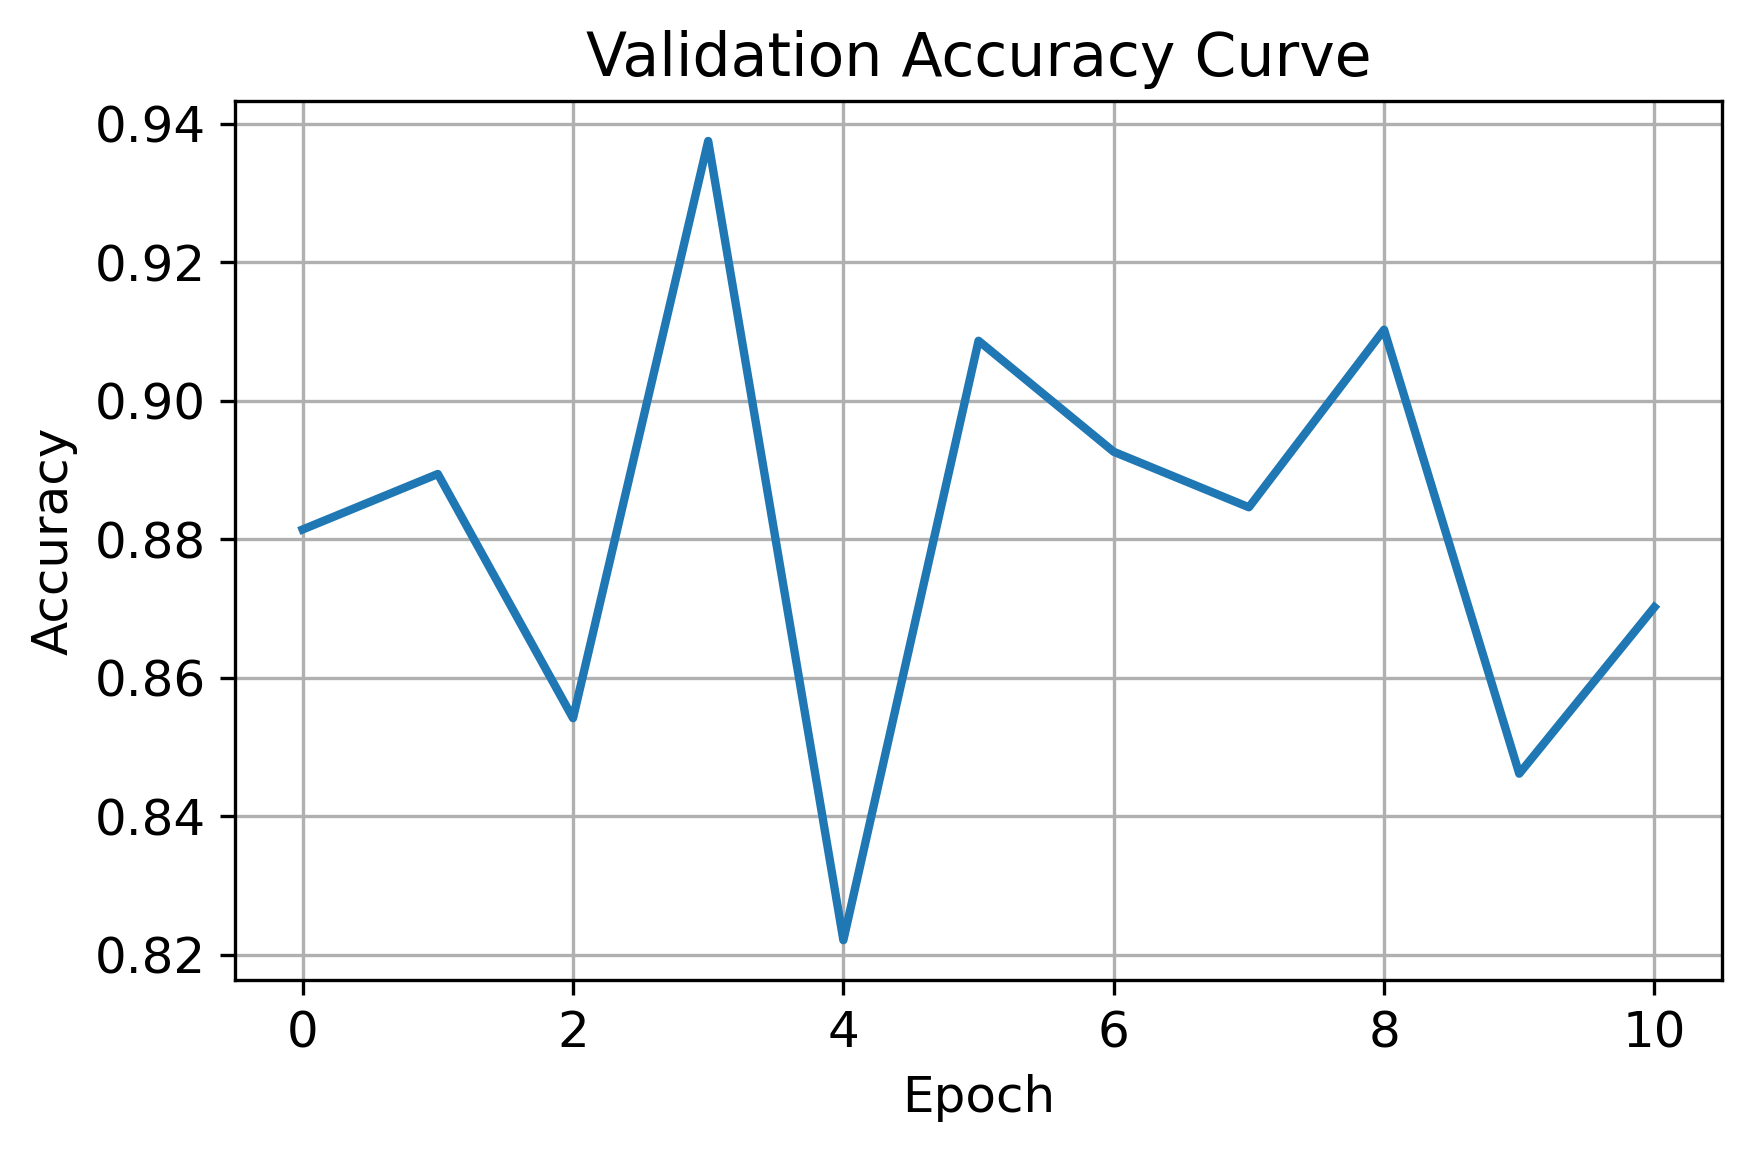

In [77]:

# Accuracy Curve
plt.figure(figsize=(6,4))
plt.plot(history["val_acc"], linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Curve")
plt.grid(True)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/validation_accuracy.png", bbox_inches="tight")
plt.show()



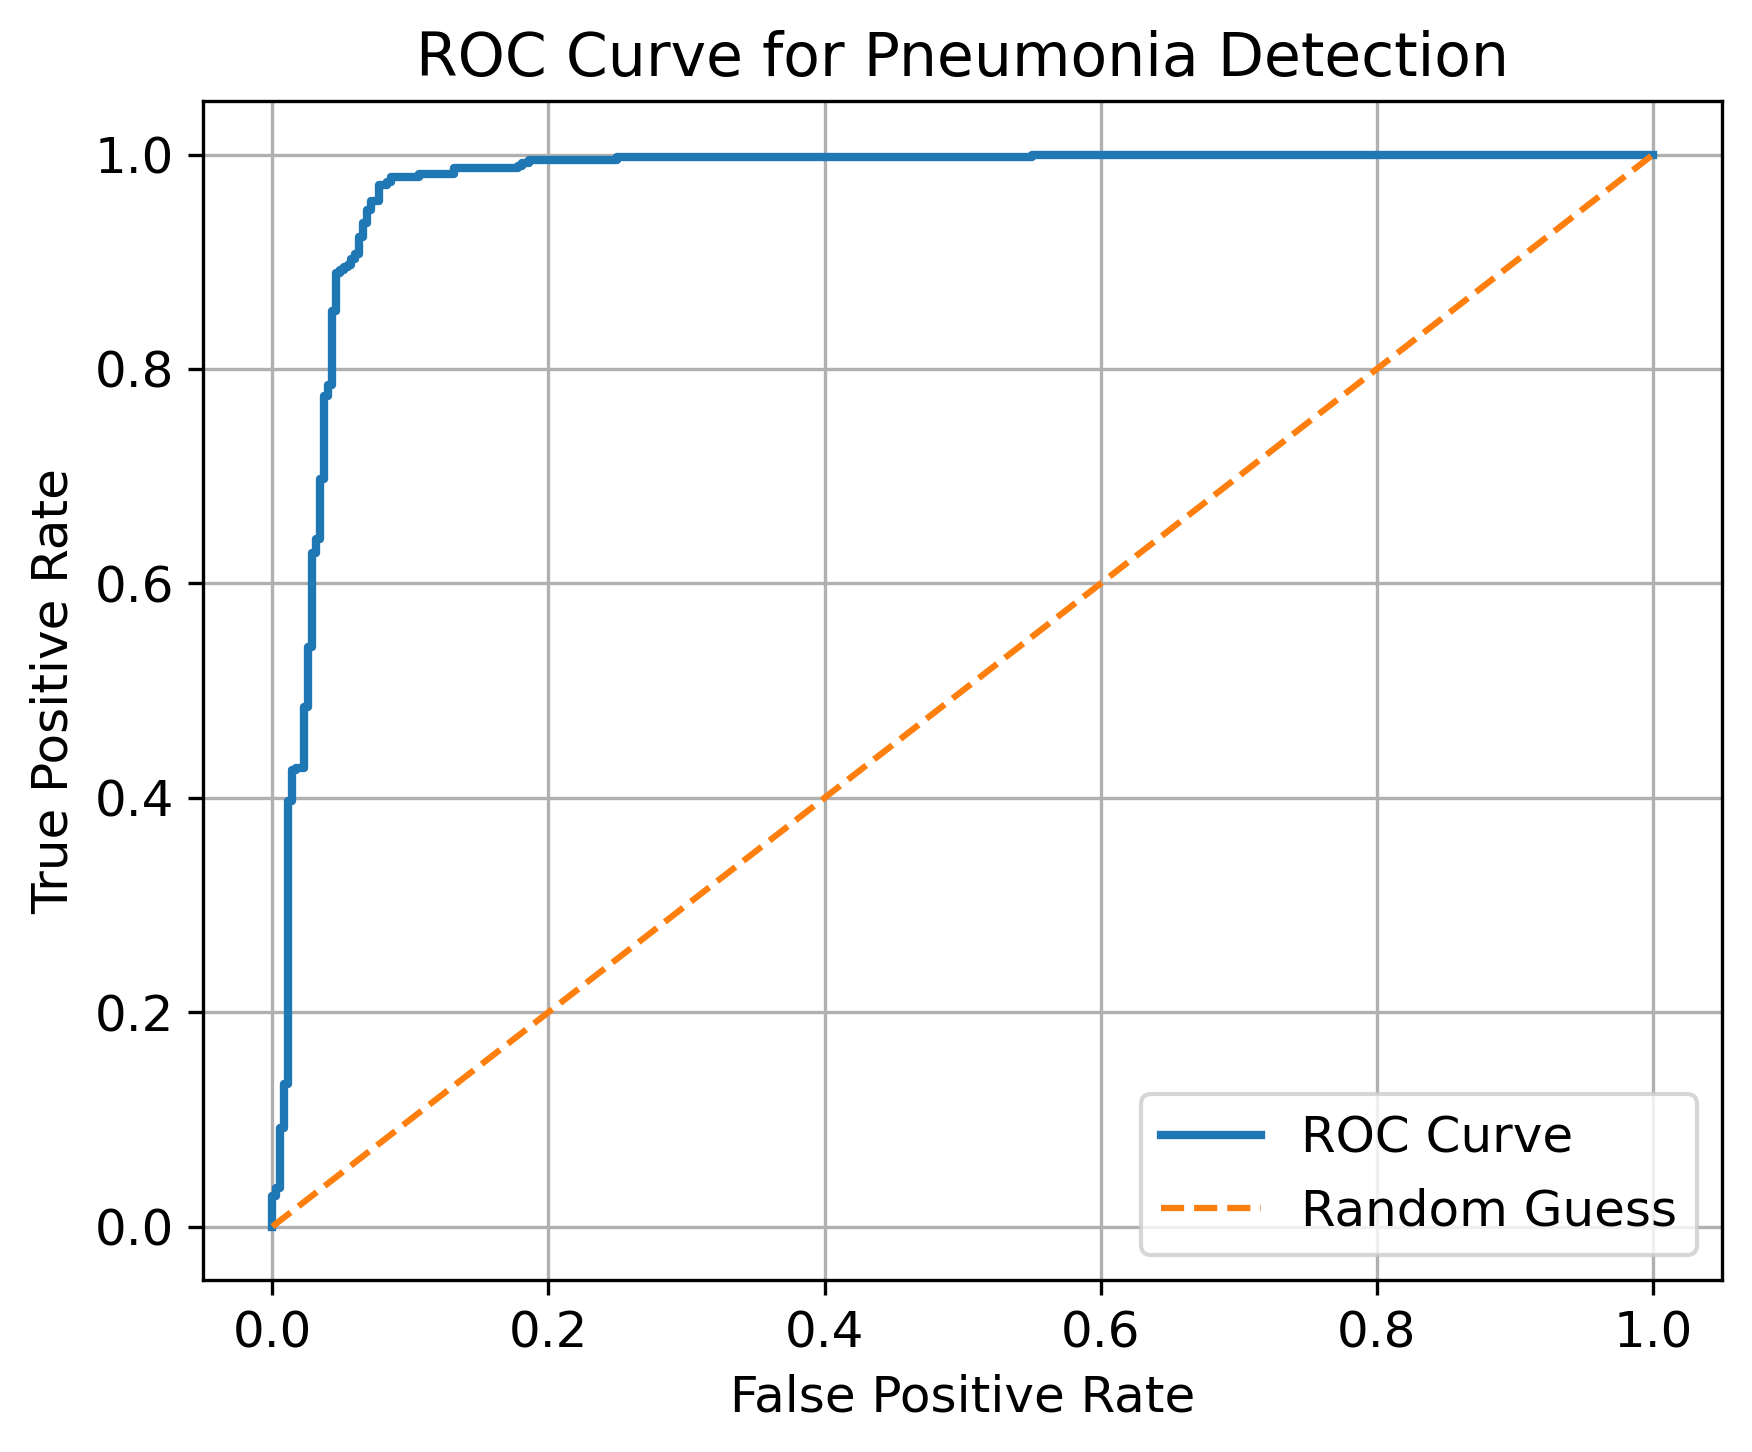

In [78]:

# ROC Curve
test_metrics = evaluate(model, test_loader)
fpr, tpr, _ = roc_curve(test_metrics["y"], test_metrics["s"])
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, linewidth=2, label="ROC Curve")
plt.plot([0,1],[0,1],'--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Pneumonia Detection")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/roc_curve.png", bbox_inches="tight")
plt.show()



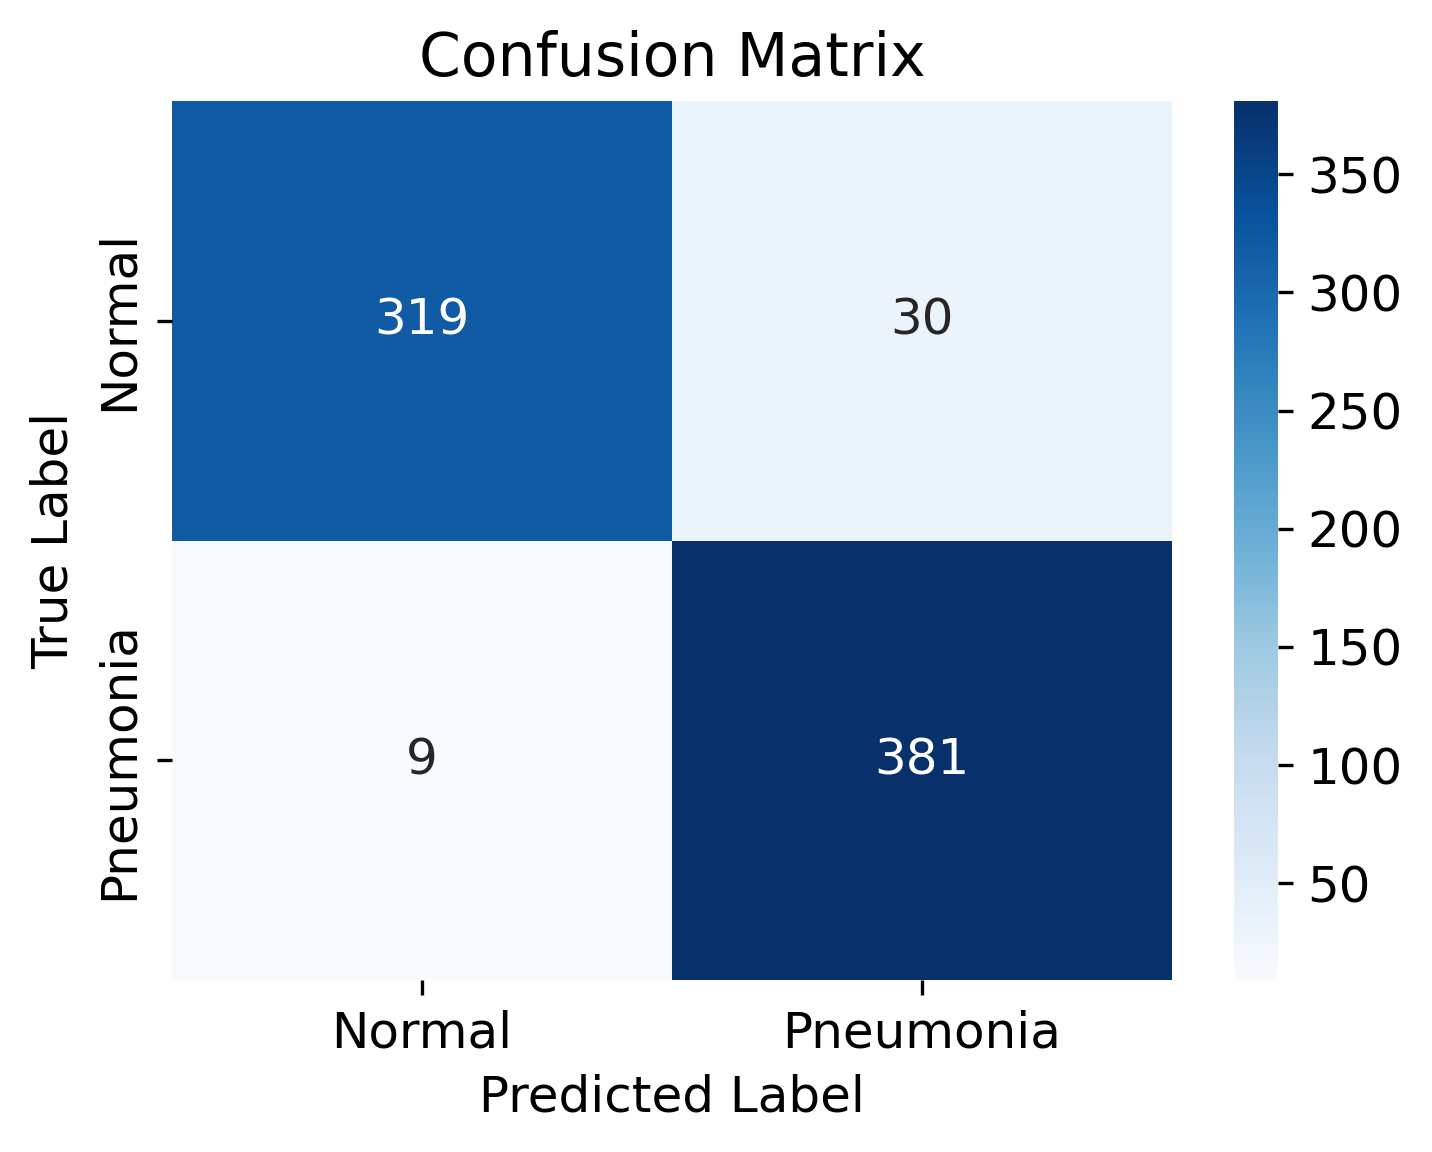

In [79]:

# Confusion Matrix
cm = confusion_matrix(test_metrics["y"], test_metrics["p"])
plt.figure(figsize=(5,4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Normal", "Pneumonia"],
    yticklabels=["Normal", "Pneumonia"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/confusion_matrix.png", bbox_inches="tight")
plt.show()



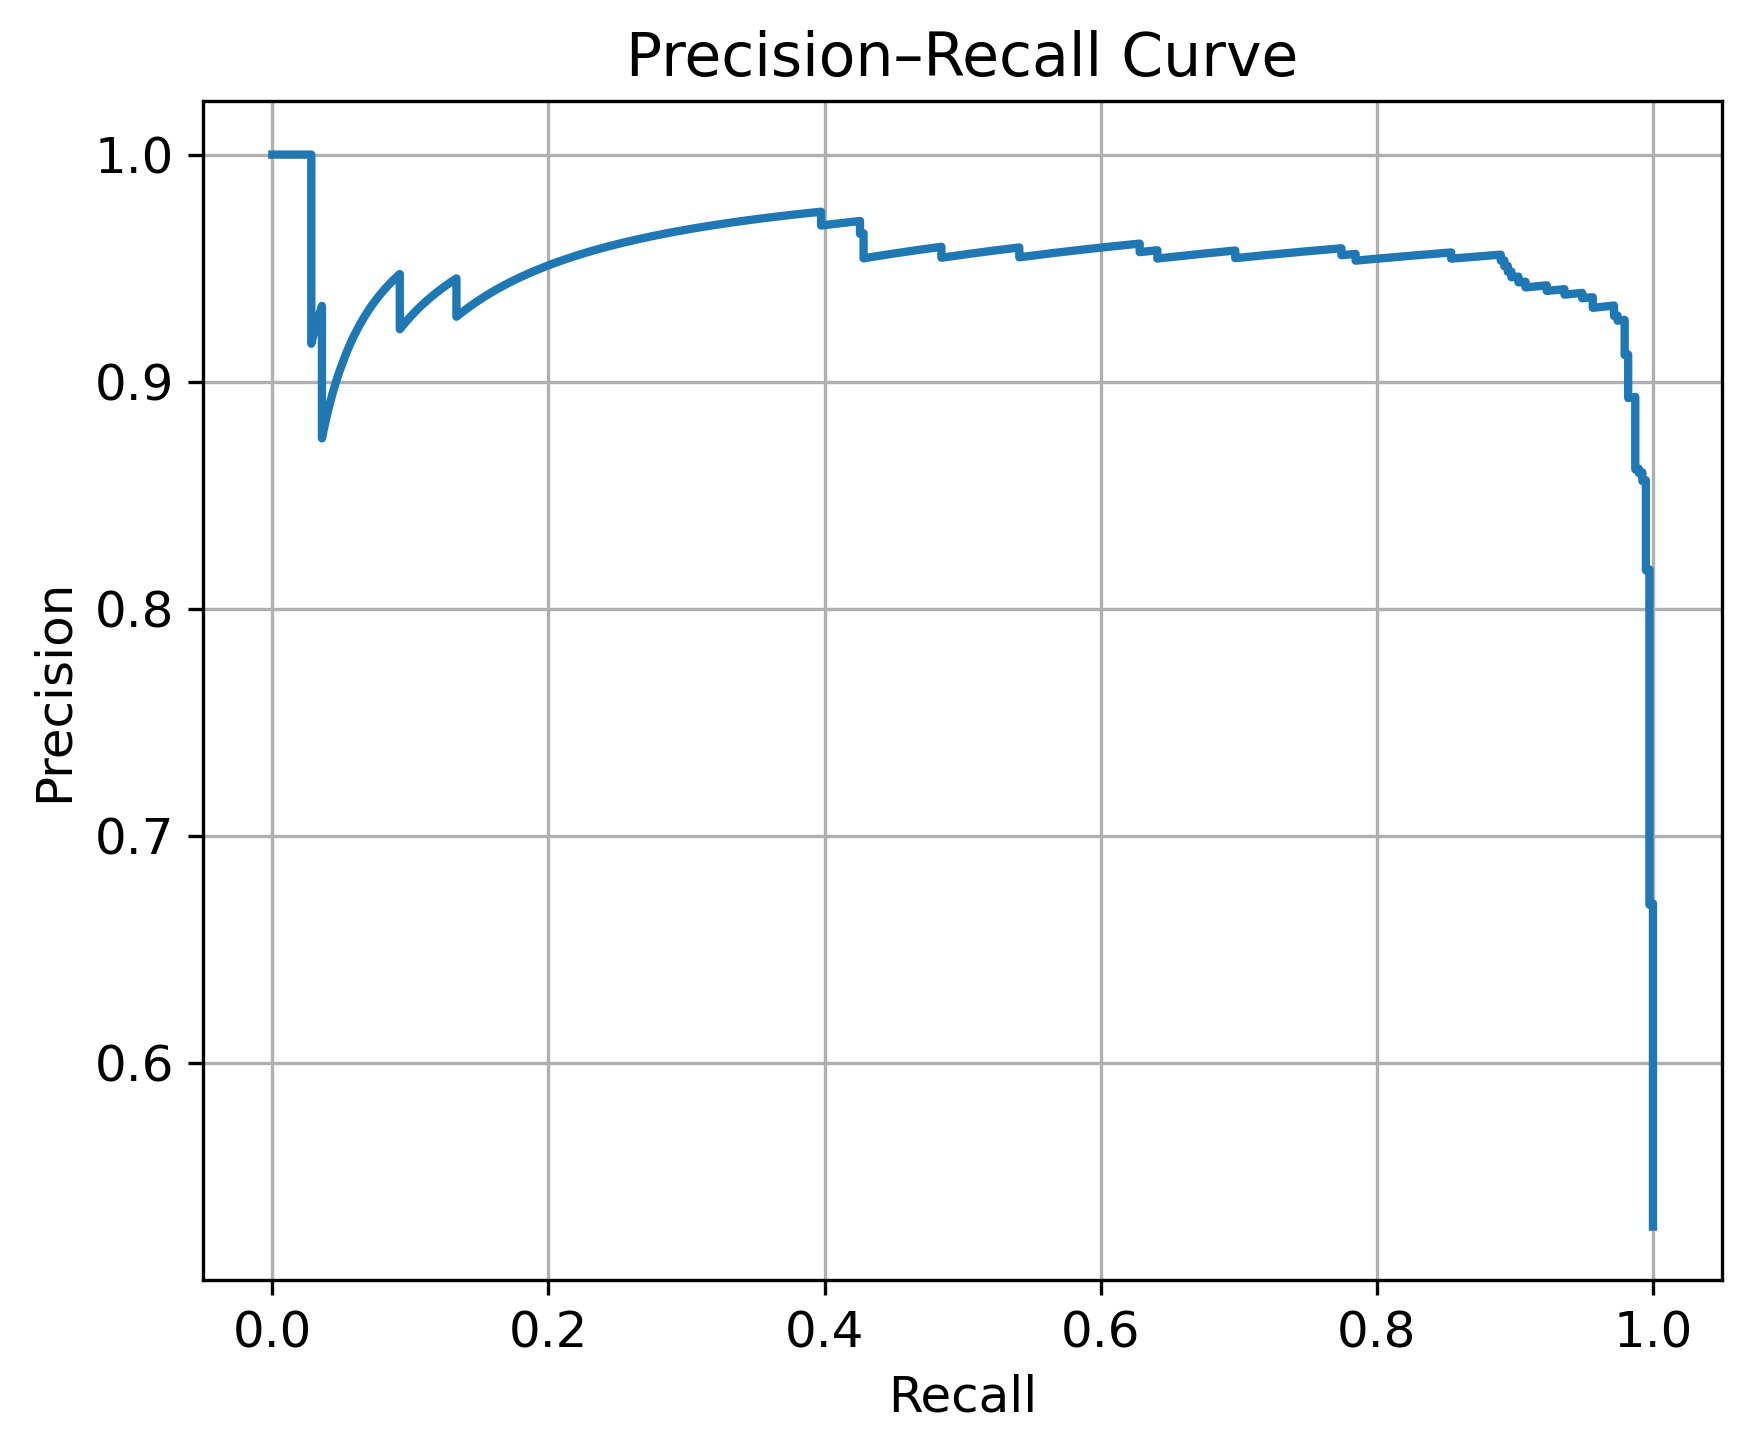

In [80]:

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(test_metrics["y"], test_metrics["s"])
plt.figure(figsize=(6,5))
plt.plot(recall, precision, linewidth=2)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.grid(True)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/precision_recall_curve.png", bbox_inches="tight")
plt.show()

